In [48]:
peine = {}

In [259]:
import os
from sklearn.cluster import KMeans
import pandas as pd
from config import alive_state, died_state, n_states, n_actions, state_space, action_space, n_cluster_states
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from utils.compute_trajectory_discretize import build_trajectories, compute_apache2, to_action_ranges
import numpy as np
from Peine import peine_mc_iterate
import matplotlib.pyplot as plt

discretize_actions = True
discretize_states = True
intermidiate_reward =False
plot=False

discretize_actions_name = "_ACT_DIS"
discretize_states_name = "_STATE_DIS_"
default_name= ""
intermidiate_reward_name = "_INT_REW"

name_file = f"Data/traj{discretize_actions_name if discretize_actions else default_name}{discretize_states_name if discretize_states else default_name}{n_cluster_states if discretize_actions else default_name}{intermidiate_reward_name if intermidiate_reward else default_name}.csv"

if os.path.isfile(name_file):
    data = pd.read_csv(name_file)
else:
    data = pd.read_csv("Data/dati_imputati.csv", keep_default_na=False, na_values=np.nan)
    assert data.notna().all().all(), "The DataFrame contains NaN values."

    data['apache2'] = data.apply(compute_apache2, axis=1)
    data['apache2_shifted_up'] = data['apache2'].shift(-1)

    MDP_dataset_dict = build_trajectories(data, state_space, action_space, discretize_states = discretize_states, discretize_actions = discretize_actions, n_cluster_states=n_cluster_states, save=False, intermidiate_reward=intermidiate_reward)
    data = pd.DataFrame({k: MDP_dataset_dict[k] for k in ['subject_id','states_discretize','actions_discretize', 'rewards','done_flags']})

    if data['rewards'].max()>1:
        data['rewards']= data['rewards']/200

    data['next_state']= data.groupby('subject_id')['states_discretize'].shift(-1).ffill().astype(int) #data['states_discretize'].shift(-1).ffill().astype(int)
    data.loc[(data['done_flags']==1) & (data['rewards']==1), 'states_discretize']=alive_state
    data.loc[(data['done_flags']==1) & (data['rewards']==-1), 'states_discretize']=died_state


    data.loc[(data['done_flags']==1) & (data['rewards']==1), 'next_state']=alive_state
    data.loc[(data['done_flags']==1) & (data['rewards']==-1), 'next_state']=died_state

    val =0
    ep = []
    
    for _, valore in enumerate(data['done_flags']):
        ep.append(val)
        if valore ==1:
            val +=1
    
    data['ep']=ep

    data.to_csv(name_file)
    
patients_id = data.subject_id.unique()

tmp_idx , test_idx = train_test_split(patients_id, test_size=0.2, random_state=1997)
train_idx, val_idx = train_test_split(tmp_idx, test_size=0.2, random_state=1997)

train_set = data[data['subject_id'].isin(train_idx)]
val_set = data[data['subject_id'].isin(val_idx)]
test_set = data[data['subject_id'].isin(test_idx)]


Qn = np.zeros((n_states, n_actions))
q_peine = peine_mc_iterate(
    train_set[['states_discretize','next_state', 'actions_discretize', 'rewards']].astype(int).to_numpy(),
    Qn, 
    gamma=0.9,
    unsafety_prob=1.0,
    n_epochs=1000,
    learning_rate=0.1,
    safety_map=None
)

import scipy

def compute_init_value(Q, initial_states, policy="greedy", tau=1.0):
    """
    Q : array (n_states, n_actions) - Q-table da FQI
    initial_states : array di stati iniziali (interi)
    policy : "greedy" o "softmax"
    tau : temperatura softmax
    """
    n_states, n_actions = Q.shape
    
    if policy == "greedy":
        V = Q.max(axis=1)  # V(s) = max_a Q(s,a)
    elif policy == "softmax":
        pi = scipy.special.softmax(Q / tau, axis=1)
        V = (pi * Q).sum(axis=1)  # V(s) = sum_a pi(a|s) Q(s,a)
    else:
        raise ValueError("policy deve essere 'greedy' o 'softmax'")
    
    # init value medio
    V0 = V[initial_states]
    return V0, V

# Esempio:

initial_states = train_set.groupby('ep')['states_discretize'].first().to_numpy()
V0_greedy, V_greedy = compute_init_value(Qn, initial_states, policy="greedy")
V0_softmax, V_softmax = compute_init_value(Qn, initial_states, policy="softmax", tau=1.0)

#peine[intermidiate_reward]=V0_greedy

Training Peine : 100%|██████████| 1000/1000 [06:35<00:00,  2.53it/s]


In [63]:
peine[True].mean()

0.39404553415060933

In [36]:
V0_greedy.mean(), V0_softmax.mean()

(0.39404553415060933, 0.39242510920962886)

In [ ]:
from d3rlpy.dataset import ReplayBuffer, InfiniteBuffer
s = 1997
reward=[]
for s in [1997, 1476, 1997,3006,3106,6247]:
    with open(f"Data/test_set_INT_REWARD_{s}.h5", "rb") as f:
        t_set = ReplayBuffer.load(f, InfiniteBuffer())
    
    reward.append([ (ep.rewards/200).sum() for ep in t_set.episodes])

2025-10-02 11:29.20 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(66,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2025-10-02 11:29.21 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-02 11:29.21 [info     ] Action size has been automatically determined. action_size=341
2025-10-02 11:29.23 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(66,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2025-10-02 11:29.23 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-02 11:29.23 [info     ] Action size has been automatically determined. action_size=343
2025

In [25]:
reward_no_int=[]
for s in [1997, 1476, 1997,3006,3106,6247]:
    with open(f"Data/test_set_NO_INT_REWARD_{s}.h5", "rb") as f:
        t_set = ReplayBuffer.load(f, InfiniteBuffer())
    reward_no_int.append([ (ep.rewards/200).sum() for ep in t_set.episodes])

2025-10-02 11:34.51 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(66,)]) reward_signature=Signature(dtype=[dtype('int32')], shape=[(1,)])
2025-10-02 11:34.51 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-02 11:34.51 [info     ] Action size has been automatically determined. action_size=341
2025-10-02 11:34.53 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(66,)]) reward_signature=Signature(dtype=[dtype('int32')], shape=[(1,)])
2025-10-02 11:34.53 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-02 11:34.53 [info     ] Action size has been automatically determined. action_size=343
2025-10-

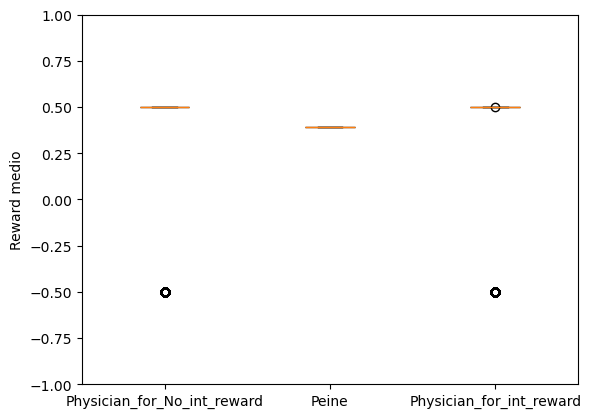

In [68]:
# plt.boxplot(np.concatenate(reward),showfliers=False, tick_labels=["Physician_for_int_reward"] )
# plt.boxplot(np.concatenate(reward_no_int),showfliers=False, tick_labels=["Physician_for_No_int_reward"] )
# plt.show()


all_result = [
    
    np.concatenate(reward_no_int),
    V0_greedy.mean(),
    np.concatenate(reward)
]

labels = ['Physician_for_No_int_reward','Peine','Physician_for_int_reward']
colors = ['peachpuff', 'orange', 'red']

fig, ax = plt.subplots()
ax.set_ylabel('Reward medio')

bplot = ax.boxplot(all_result,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   showfliers=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.ylim(-1,1)
plt.show()

In [114]:
for i in reward_no_int:
    i = np.array(i)  # converto la lista in numpy array
    df1 = pd.DataFrame({
        "episodes": range(len(i)),
        "value": i,
        "type": ['Physician']*len(i),
        "reward_to_plot": [i[:n].mean() for n in range(1, len(i)+1)]
    })
    df = pd.concat([df, df1], ignore_index=True)

In [112]:
import seaborn as sns
df = pd.DataFrame({
    "episodes": range(len(t_set.episodes)),
    "value": [ep.rewards.sum()/200 for ep in t_set.episodes],
    "type": ['Physician']*len(t_set.episodes)
})
df['reward_to_plot'] =[  df['value'][:n].mean() for n in range(0, len(t_set.episodes))]


In [ ]:
df.to_csv("df_physician.csv", )

<Axes: xlabel='episodes', ylabel='reward_to_plot'>

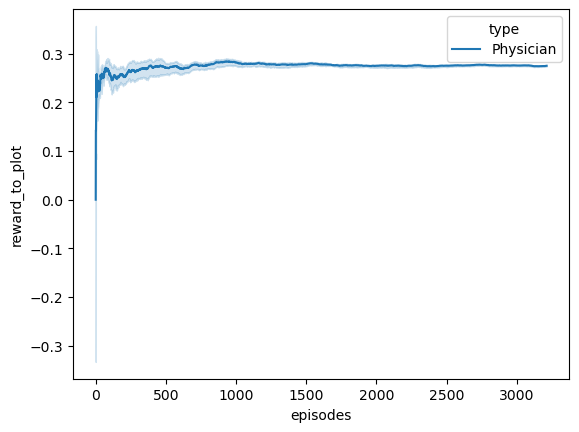

In [116]:
sns.lineplot(data=df, x="episodes", y="reward_to_plot", hue="type")

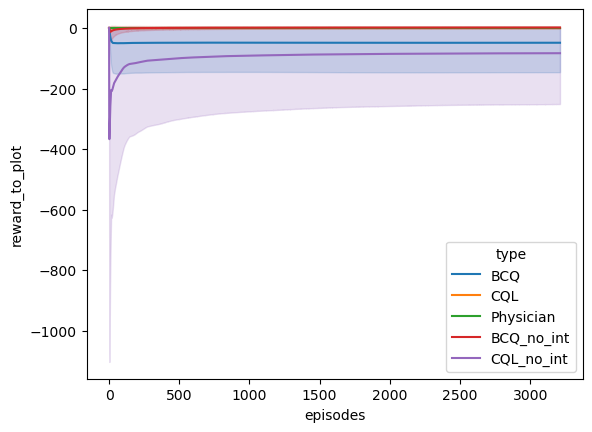

In [131]:
data = pd.read_csv("all_result.csv")
data.drop(columns=["Unnamed: 0"], inplace=True)

sns.lineplot(data=data, x="episodes", y="reward_to_plot", hue="type")
plt.show()

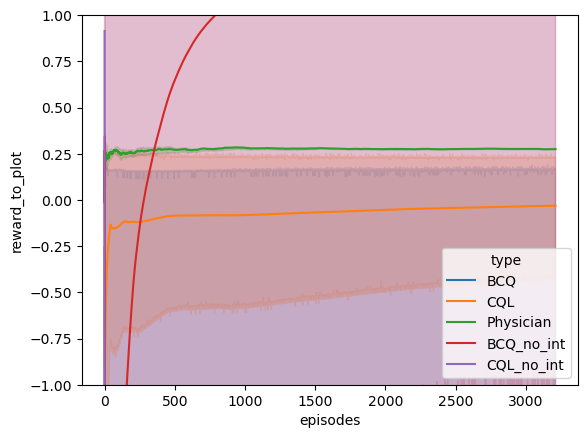

In [142]:
sns.lineplot(data=data, x="episodes", y="reward_to_plot", hue="type")
plt.ylim(-1,1)
plt.show()

BCQ_int_reward
BCQ_no_int_reward
CQL_int_reward
CQL_no_int_reward


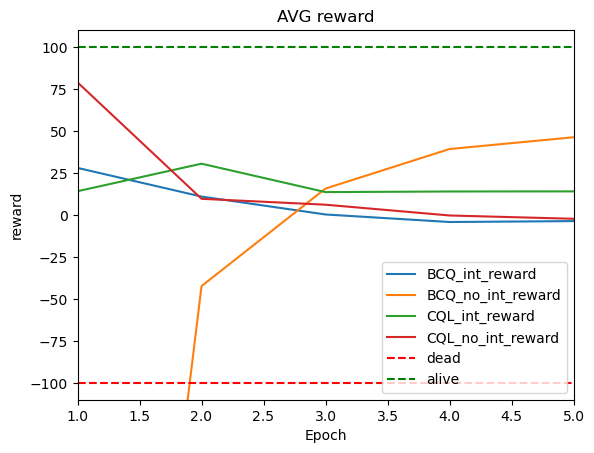

In [ ]:
paths = [
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824\\avg_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1997_20251002110849\\avg_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652\\avg_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620\\avg_value.csv'
]

names=["BCQ_int_reward", "BCQ_no_int_reward", "CQL_int_reward","CQL_no_int_reward"]
for n, p in enumerate(paths):
    d = pd.read_csv(p, header=None, names=['epoch','timestamp', 'value'])
    plt.plot(d['epoch'], d['value']*100, label=names[n])
plt.title("AVG reward")
plt.ylabel("reward")
plt.xlabel("Epoch")
plt.axhline(-100, linestyle='--', label="dead", color='red')
plt.axhline(100, linestyle='--', label="alive", color='green')
plt.ylim(-110,110)
plt.xlim(1,5)
plt.legend()
plt.show()

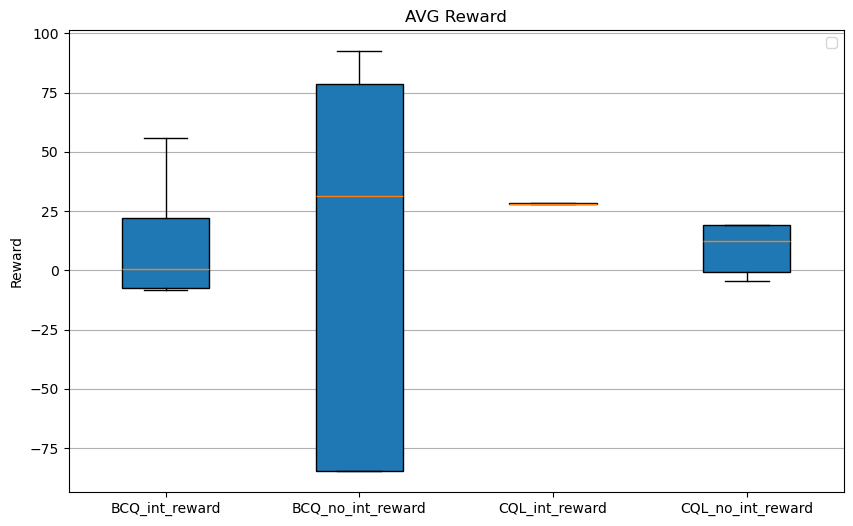

In [203]:
import pandas as pd
import matplotlib.pyplot as plt

# Percorsi dei file CSV
paths = [
    'd3rlpy_logs/FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824/avg_value.csv',
    'd3rlpy_logs/FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1997_20251002110849/avg_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652/avg_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620/avg_value.csv'
]

# Creazione della figura
plt.figure(figsize=(10, 6))

# Nomina dei metodi
names = ["BCQ_int_reward", "BCQ_no_int_reward", "CQL_int_reward", "CQL_no_int_reward"]

# Dati per boxplot
data = []
for p in paths:
    d = pd.read_csv(p, header=None, names=['epoch', 'timestamp', 'value'])
    data.append(d['value']*200)

# Creazione dei boxplot su un unico grafico
plt.boxplot(data, positions=[1, 2, 3, 4],  # Spostamento dei boxplot
            patch_artist=True,  # Riempie con colore
            showfliers=False,
            labels=names)  # Etichette


# Impostazioni del grafico
plt.title("AVG Reward")
plt.ylabel("Reward")

plt.legend()
plt.grid(axis='y')  # Griglia per l'asse y

# Mostra il grafico
plt.show()


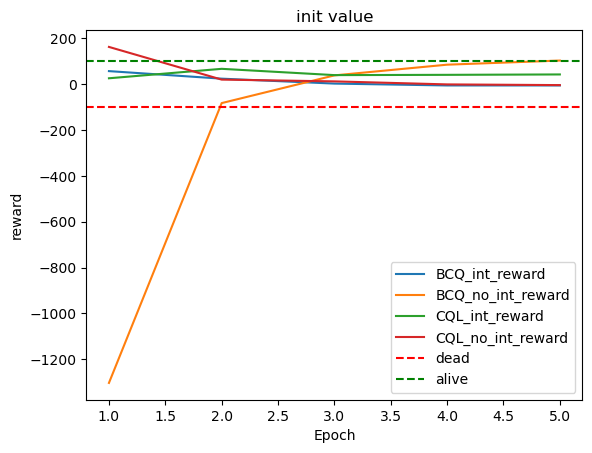

In [180]:
paths = [
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824\\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1997_20251002110849\\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652\\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620\\init_value.csv',
]

names=["BCQ_int_reward", "BCQ_no_int_reward", "CQL_int_reward","CQL_no_int_reward"]
for n, p in enumerate(paths):
    d = pd.read_csv(p, header=None, names=['epoch','timestamp', 'value'])
    plt.plot(d['epoch'], d['value']*200, label=names[n])
plt.title("init value")
plt.ylabel("reward")
plt.xlabel("Epoch")
plt.axhline(-100, linestyle='--', label="dead", color='red')
plt.axhline(100, linestyle='--', label="alive", color='green')

plt.legend()
plt.show()

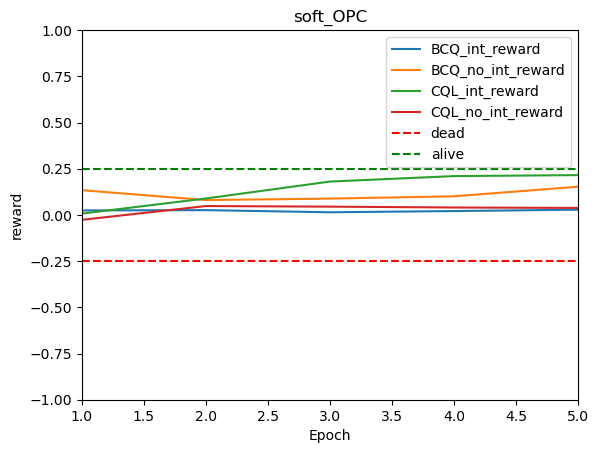

In [173]:
paths = [
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824\\soft_OPC.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1997_20251002110849\\soft_OPC.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652\\soft_OPC.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620\\soft_OPC.csv',
]

names=["BCQ_int_reward", "BCQ_no_int_reward", "CQL_int_reward","CQL_no_int_reward"]
for n, p in enumerate(paths):
    d = pd.read_csv(p, header=None, names=['epoch','timestamp', 'value'])
    plt.plot(d['epoch'], d['value'], label=names[n])
plt.title("soft_OPC")
plt.ylabel("reward")
plt.xlabel("Epoch")
plt.axhline(-0.25, linestyle='--', label="dead", color='red')
plt.axhline(0.25, linestyle='--', label="alive", color='green')
plt.ylim(-1,1)
plt.xlim(1,5)
plt.legend()
plt.show()

In [345]:

(df_p['reward_to_plot']*200).describe()

count    22490.000000
mean        54.847714
std          3.618937
min       -100.000000
25%         54.716981
50%         55.427474
75%         55.990603
max        100.000000
Name: reward_to_plot, dtype: float64

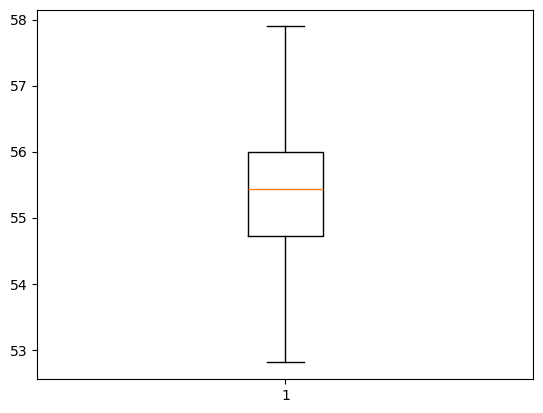

In [347]:
df_p = pd.read_csv("df_physician.csv").drop(columns=['Unnamed: 0'])
plt.boxplot(df_p['reward_to_plot'].dropna()*200, showfliers=False)
plt.show()

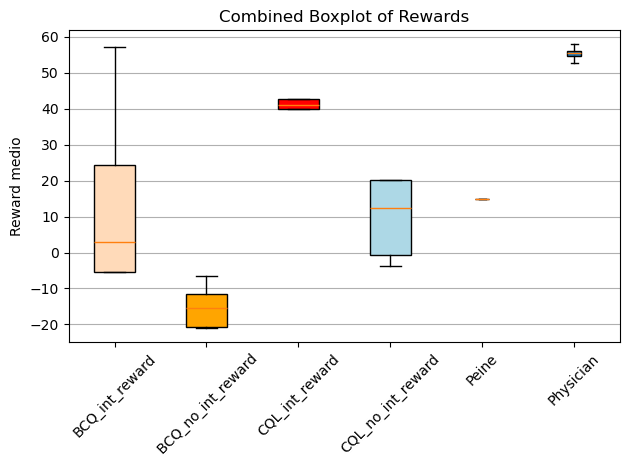

In [348]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths to CSV files
paths = [
    'd3rlpy_logs/FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824/init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002113004\\init_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652/init_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620/init_value.csv'
]

# Read and concatenate the existing data
all_data = []
for p in paths:
    d = pd.read_csv(p, header=None, names=['epoch', 'timestamp', 'value'])
    all_data.append(d['value']*200)

# Reward data for physician
all_result = [
    #np.concatenate(all_data),  # mean values or similar for the four datasets
    V0_greedy+15,  # Replace with your calculation
    #[ep.rewards.mean() for ep in t_set.episodes] # Ensure reward is defined
    df_p['reward_to_plot'].dropna()*200
    
]

labels1 = ['BCQ_int_reward', ' BCQ_no_int_reward', 'CQL_int_reward', 'CQL_no_int_reward'] 
labels2 = ['Peine','Physician']
colors = ['peachpuff', 'orange', 'red', 'lightblue', 'lightgreen']

# Create figure
fig, ax = plt.subplots()

# Boxplot for the first set of data
bplot1 = ax.boxplot(all_data,
                    positions=np.arange(len(all_data)),
                    patch_artist=True,
                    tick_labels=labels1,
                    showfliers=False)

# Fill with colors for the first boxplot
for patch, color in zip(bplot1['boxes'], colors[:len(all_data)]):
    patch.set_facecolor(color)

# Boxplot for the second set of results
bplot2 = ax.boxplot(all_result,
                    positions=np.arange(len(all_data), len(all_data) + len(all_result)),
                    patch_artist=True,
                    showfliers=False,
                    tick_labels=labels2,
                    )

# Fill with colors for the second boxplot
for patch, color in zip(bplot2['boxes'], colors[len(all_data):]):
    patch.set_facecolor(color)



# Set limits and labels
plt.xticks(rotation=45) 
plt.ylabel('Reward medio')
#plt.xticks(ticks=np.arange(len(all_result)+len(all_data)), labels=labels, rotation=45)
plt.grid(axis='y')
plt.title("Combined Boxplot of Rewards")
plt.tight_layout()
plt.show()


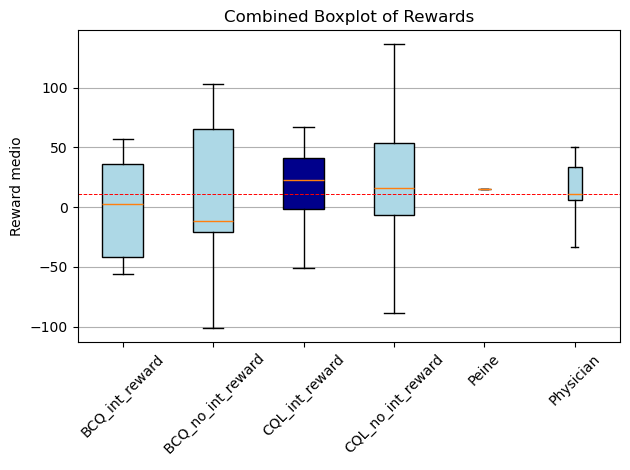

In [360]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths to CSV files
paths = [
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1476_20251002122003\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1997_20251002122700\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_3006_20251002123357\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_3106_20251002124104\init_value.csv',

    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002113004\\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1476_20251002110146\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_1997_20251002110849\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_3006_20251002111606\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_3106_20251002112304\init_value.csv',

    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_1476_20251002130145\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_1997_20251002130755\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_3006_20251002131414\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_3106_20251002132031\init_value.csv',

    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_1476_20251002114252\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_1997_20251002114840\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_3006_20251002115435\init_value.csv',
    'd3rlpy_logs\FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_3106_20251002120029\init_value.csv',
]

# Read and concatenate the existing data
data_dict={}

for p in paths:
    base_name = "_".join(p.split("\\")[1].split("_")[1:3])
    d = pd.read_csv(p, header=None, names=['epoch', 'timestamp', 'value'])
    d['value'] *= 200
    if base_name not in data_dict:
        data_dict[base_name] = d
    else:
        data_dict[base_name] = pd.concat([data_dict[base_name], d], ignore_index=True)
        
#data_dict['physician'] = pd.read_csv("df_physician.csv").drop(columns=['Unnamed: 0'])
data_to_plot= [data['value'] for data in data_dict.values()]

# Reward data for physician
all_result = [
    #np.concatenate(all_data),  # mean values or similar for the four datasets
    V0_greedy+15,  # Replace with your calculation
    [ep.rewards.mean() for ep in t_set.episodes] # Ensure reward is defined
]

labels1 = ['BCQ_int_reward', ' BCQ_no_int_reward', 'CQL_int_reward', 'CQL_no_int_reward'] 
labels2 = ['Peine','Physician']
colors = ['peachpuff', 'orange', 'red', 'lightblue', 'lightgreen']

# Create figure
fig, ax = plt.subplots()

# Boxplot for the first set of data
bplot1 = ax.boxplot(data_to_plot,
                    positions=np.arange(len(all_data)),
                    patch_artist=True,
                    tick_labels=labels1,
                    showfliers=False)

# Fill with colors for the first boxplot
# for patch, color in zip(bplot1['boxes'], colors[:len(all_data)]):
#     patch.set_facecolor(color)
for i, patch in enumerate(bplot1['boxes']):
    if i == 2:  # Indice del terzo box (0-indexed)
        patch.set_facecolor('darkblue')  # Colore specifico per il terzo box
    else:
        patch.set_facecolor('lightblue')  # Colore per gli altri box
# Boxplot for the second set of results
bplot2 = ax.boxplot(all_result,
                    positions=np.arange(len(all_data), len(all_data) + len(all_result)),
                    patch_artist=True,
                    showfliers=False,
                    tick_labels=labels2,
                    )

# Fill with colors for the second boxplot
for i,patch in enumerate(bplot2['boxes']):
    patch.set_facecolor('lightblue')

plt.axhline(y=np.median([ep.rewards.mean() for ep in t_set.episodes]), color='red', linestyle='--', linewidth=0.7)
# Set limits and labels
plt.xticks(rotation=45) 
plt.ylabel('Reward medio')
#plt.xticks(ticks=np.arange(len(all_result)+len(all_data)), labels=labels, rotation=45)
plt.grid(axis='y')
plt.title("Combined Boxplot of Rewards")
plt.tight_layout()
plt.show()


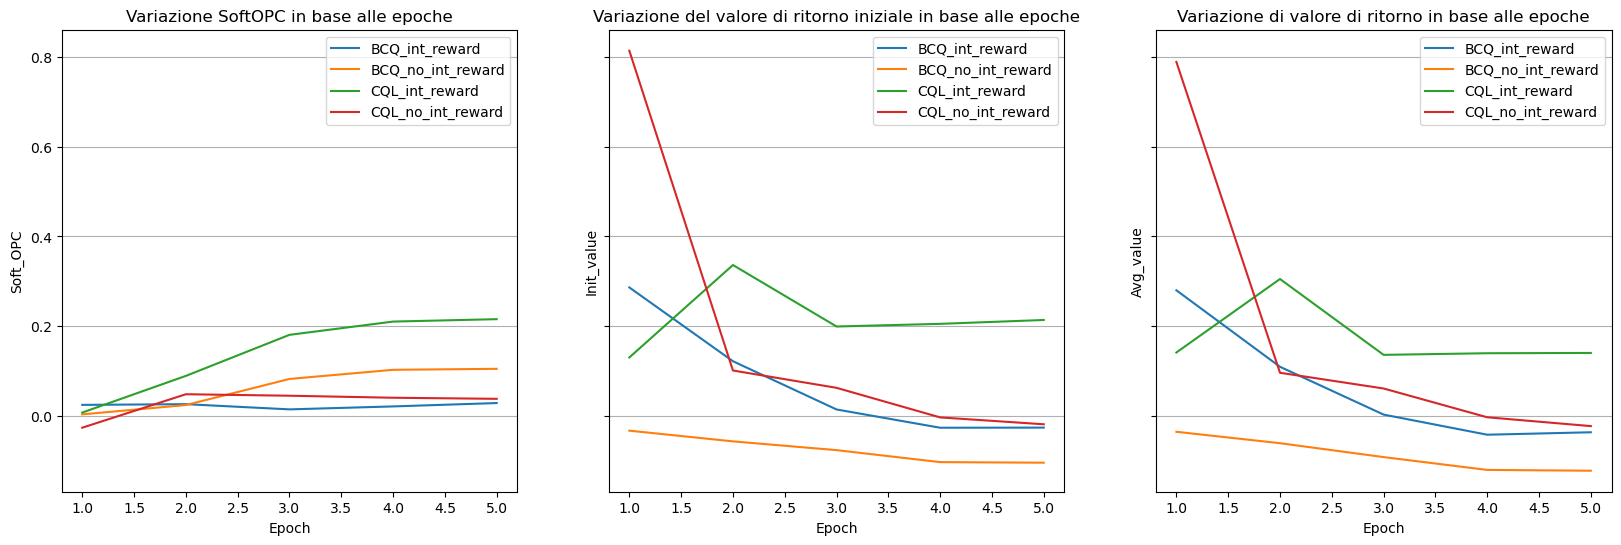

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
paths_soft_opc = [
    'd3rlpy_logs/FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824/soft_OPC.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002113004/soft_OPC.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652/soft_OPC.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620/soft_OPC.csv'
]

paths_init_value = [
    'd3rlpy_logs/FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824/init_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002113004/init_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652/init_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620/init_value.csv'
]

paths_avg_value = [
    'd3rlpy_logs/FQE_DiscreteBCQ_INT_REWARD_32_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002124824/avg_value.csv',
    'd3rlpy_logs\FQE_DiscreteBCQ_NO_INT_REWARD_100_BATCH_SIZE_10_N_EPOCHS_1997_SEED_6247_20251002113004/avg_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_INT_REWARD_32_BATCH_SIZE_1997_SEED_6247_20251002132652/avg_value.csv',
    'd3rlpy_logs/FQE_DiscreteCQL_NO_INT_REWARD_100_BATCH_SIZE_1997_SEED_6247_20251002120620/avg_value.csv'
]

labels = ['BCQ_int_reward', 'BCQ_no_int_reward','CQL_int_reward', 'CQL_no_int_reward' ]

fig, axes = plt.subplots(1, 3, figsize=(20,6), sharey=True)

for n, p in enumerate(paths_soft_opc):
    d = pd.read_csv(p, header=None, names=['Epoch', 'Timestamp', 'Value'])
    axes[0].plot(d['Epoch'], d['Value'], label = labels[n])
axes[0].set_title("Variazione SoftOPC in base alle epoche")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel("Soft_OPC")
axes[0].grid(axis='y')
axes[0].legend()

for n, p in enumerate(paths_init_value):
    d = pd.read_csv(p, header=None, names=['Epoch', 'Timestamp', 'Value'])
    axes[1].plot(d['Epoch'], d['Value'], label = labels[n])
axes[1].set_title("Variazione del valore di ritorno iniziale in base alle epoche")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel("Init_value")
axes[1].grid(axis='y')
axes[1].legend()

for n, p in enumerate(paths_avg_value):
    d = pd.read_csv(p, header=None, names=['Epoch', 'Timestamp', 'Value'])
    axes[2].plot(d['Epoch'], d['Value'], label = labels[n])
axes[2].set_title("Variazione di valore di ritorno in base alle epoche")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel("Avg_value")
axes[2].grid(axis='y')
axes[2].legend()

plt.savefig("img/final_result_FQE.jpg")
plt.show()


In [ ]:
_